# Question 1

Image shape: (1448, 1928)
Data type: uint8


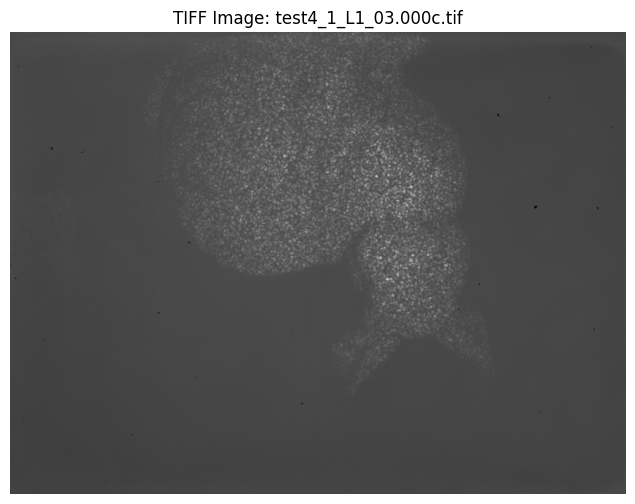

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Path to your TIFF file
file_path = "provided_resource/dataset_part_2/test4_1_L1_03.000c.tif"

# Read the TIFF file with OpenCV
try:
    # Use IMREAD_UNCHANGED to preserve the original data (e.g., 16-bit or multi-channel)
    img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
    
    # Check if the image loaded successfully
    if img is None:
        raise Exception("Image not loaded properly")
    
    # Display basic info
    print(f"Image shape: {img.shape}")
    print(f"Data type: {img.dtype}")
    
# Convert to RGB if it’s BGR, or keep as is if single-channel
    if len(img.shape) == 3 and img.shape[2] == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img
    
    # If RGB, convert to grayscale for FFT (or use a single channel)
    if len(img_rgb.shape) == 3:
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_rgb
    
    # Plot the image
    plt.figure(figsize=(8, 6))  # Set figure size (optional)
    plt.imshow(img_gray, cmap='gray' if len(img.shape) == 2 else None)  # Grayscale or RGB
    plt.title("TIFF Image: test4_1_L1_03.000c.tif")
    plt.axis('off')  # Hide axes (optional)
    plt.show()

except Exception as e:
    print(f"Error: {e}")

fshift shape: (1448, 1928)


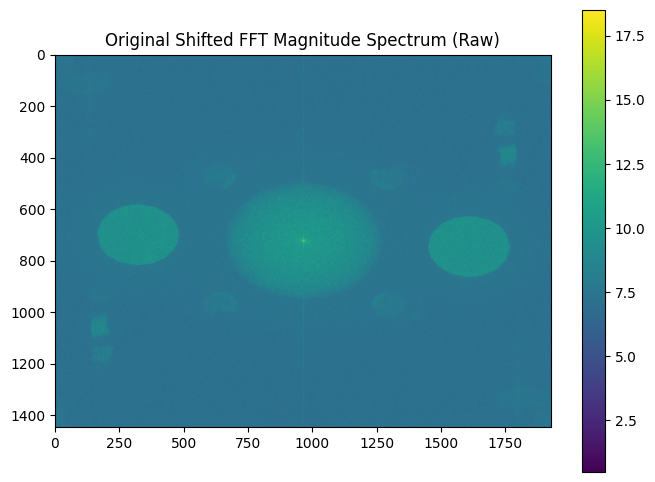

crop info y: 15:1448 ;x: 645:1928
paste info y: 0:1433 ;x: 0:1283


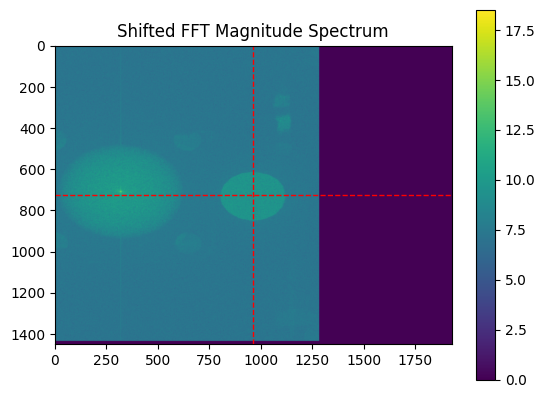

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack

def compute_fft_spectrum(image):
    """Compute 2D FFT and shift DC to center"""
    f_transform = fftpack.fft2(image)
    f_transform_shifted = fftpack.fftshift(f_transform)
    spectrum = np.abs(f_transform_shifted)
    return f_transform_shifted, spectrum


_,spectrum = compute_fft_spectrum(img_gray)
spectrum = np.log(spectrum )
print(f"fshift shape: {spectrum.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(spectrum, cmap='viridis')
plt.title("Original Shifted FFT Magnitude Spectrum (Raw)")
plt.colorbar()
plt.show()

""" Variable Fields """
num_pixels = 100
FT_img = spectrum 
R = 20 # Radius of the circle in the FT image
""" End of Variable Fields """

""" Sample code for shifting side band for Part 2 """
def shifting(FT_img, shift_OX, shift_OY):
    """
    Shifts an image by the specified number of pixels in X and Y directions.
    
    Parameters:
        FT_img: Input image array
        shift_OX: Number of pixels to shift in X direction (negative = left, positive = right)
        shift_OY: Number of pixels to shift in Y direction (negative = up, positive = down)
    
    Returns:
        Shifted image array
    """
    num_pixels_y, num_pixels_x = FT_img.shape[:2]
    
    # Determine source and destination regions for X-axis shift
    if shift_OX < 0:  # Shift left
        dest_start_x = 0
        dest_end_x = num_pixels_x + shift_OX  # This will be less than num_pixels_x
        src_start_x = -shift_OX
        src_end_x = num_pixels_x
    else:  # Shift right or no shift
        dest_start_x = shift_OX
        dest_end_x = num_pixels_x
        src_start_x = 0
        src_end_x = num_pixels_x - shift_OX
    
    # Determine source and destination regions for Y-axis shift
    if shift_OY < 0:  # Shift up
        dest_start_y = 0
        dest_end_y = num_pixels_y + shift_OY  # This will be less than num_pixels_y
        src_start_y = -shift_OY
        src_end_y = num_pixels_y
    else:  # Shift down or no shift
        dest_start_y = shift_OY
        dest_end_y = num_pixels_y
        src_start_y = 0
        src_end_y = num_pixels_y - shift_OY
    
    print(f"crop info y: {src_start_y}:{src_end_y} ;x: {src_start_x}:{src_end_x}")
    print(f"paste info y: {dest_start_y}:{dest_end_y} ;x: {dest_start_x}:{dest_end_x}")
    
    # Create output image with zeros
    FT_shift = np.zeros_like(FT_img)
    
    # Copy the source region to the destination region
    FT_shift[dest_start_y:dest_end_y, dest_start_x:dest_end_x] = FT_img[src_start_y:src_end_y, src_start_x:src_end_x]
    
    return FT_shift

# Usage
FT_horiz_OX_shift = -645  # Shift left by 1205 pixels
FT_horiz_OY_shift = -15    # Shift up by 50 pixels
FT_horiz_1 = shifting(FT_img, FT_horiz_OX_shift, FT_horiz_OY_shift)
plt.imshow(FT_horiz_1)
plt.title("Shifted FFT Magnitude Spectrum")
# Add red dashed lines at the middle of x and y axes
height, width = FT_horiz_1.shape  # (1448, 1928)
mid_x = width // 2  # 964
mid_y = height // 2  # 724

plt.axvline(x=mid_x, color='red', linestyle='--', linewidth=1)  # Vertical line (x-axis)
plt.axhline(y=mid_y, color='red', linestyle='--', linewidth=1)  # Horizontal line (y-axis)

plt.axis('on')  # Turn on axes to see the lines clearly
plt.colorbar()
plt.show()


# Question 2 
filter out the image


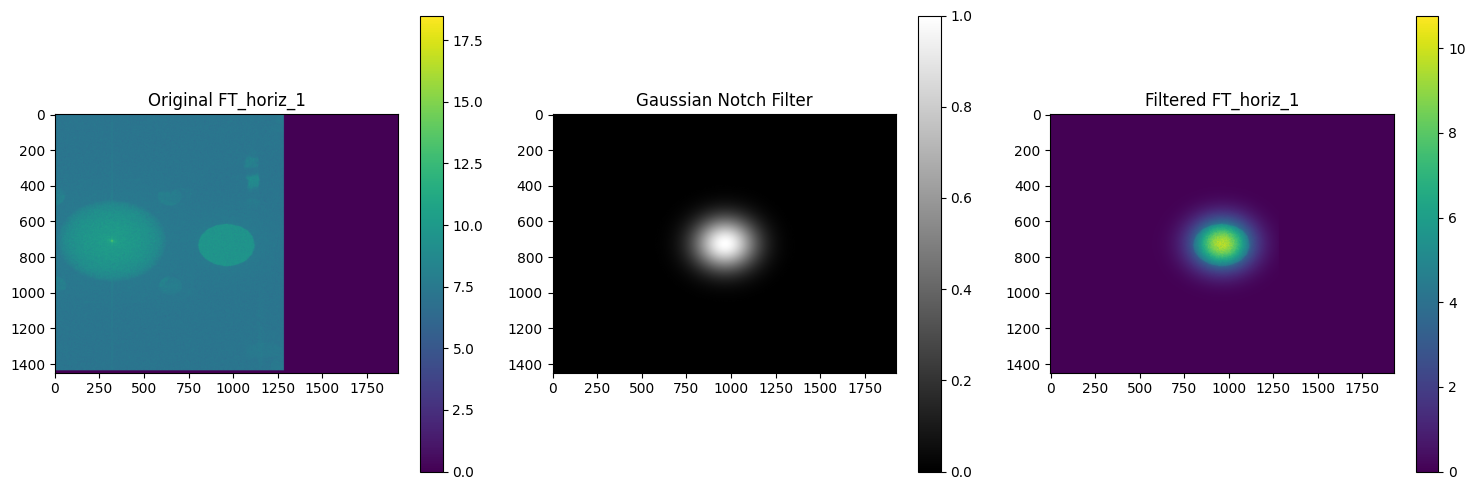

In [10]:
from scipy.ndimage import gaussian_filter

def create_gaussian_notch_filter(shape, center_y, center_x, sigma_y, sigma_x, notch_type='reject'):
    """
    Create a Gaussian notch filter to remove/keep a specific frequency region.
    
    Parameters:
        shape: Tuple of image dimensions (height, width)
        center_y, center_x: Center coordinates of the ellipse to filter
        sigma_y, sigma_x: Standard deviations of the Gaussian in y and x directions
        notch_type: 'reject' to remove the frequencies, 'pass' to keep only those frequencies
    
    Returns:
        2D numpy array representing the filter (values between 0 and 1)
    """
    y, x = np.ogrid[:shape[0], :shape[1]]
    
    # Calculate distance from center (normalized by sigma to create ellipse)
    distance = ((y - center_y)**2 / (2 * sigma_y**2)) + ((x - center_x)**2 / (2 * sigma_x**2))
    
    # Create Gaussian filter (inverted for notch reject)
    h = np.exp(-distance)
    
    # Convert between reject and pass filters
    if notch_type == 'reject':
        return 1 - h
    else:  # 'pass'
        return h

# Get dimensions of FT_horiz_1
height, width = FT_horiz_1.shape  # (1448, 1928)
mid_x = width // 2  # 964
mid_y = height // 2  # 724


# Size of the elliptical feature (standard deviations)
sigma_y, sigma_x = 100, 120  # Adjust these to match the spread of the ellipse

# Create the notch filter
notch_filter = create_gaussian_notch_filter((height, width), mid_y, mid_x, sigma_y, sigma_x,'pass')

# Apply the filter to FT_horiz_1
filtered_FT = FT_horiz_1 * notch_filter

# Plot original and filtered spectrum
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(FT_horiz_1, cmap='viridis')  # log scale for better visualization
plt.title('Original FT_horiz_1')
plt.colorbar()

plt.subplot(132)
plt.imshow(notch_filter, cmap='gray')
plt.title('Gaussian Notch Filter')
plt.colorbar()

plt.subplot(133)
plt.imshow(filtered_FT, cmap='viridis')  # log scale for better visualization
plt.title('Filtered FT_horiz_1')
plt.colorbar()

plt.tight_layout()
plt.show()


# Question 3

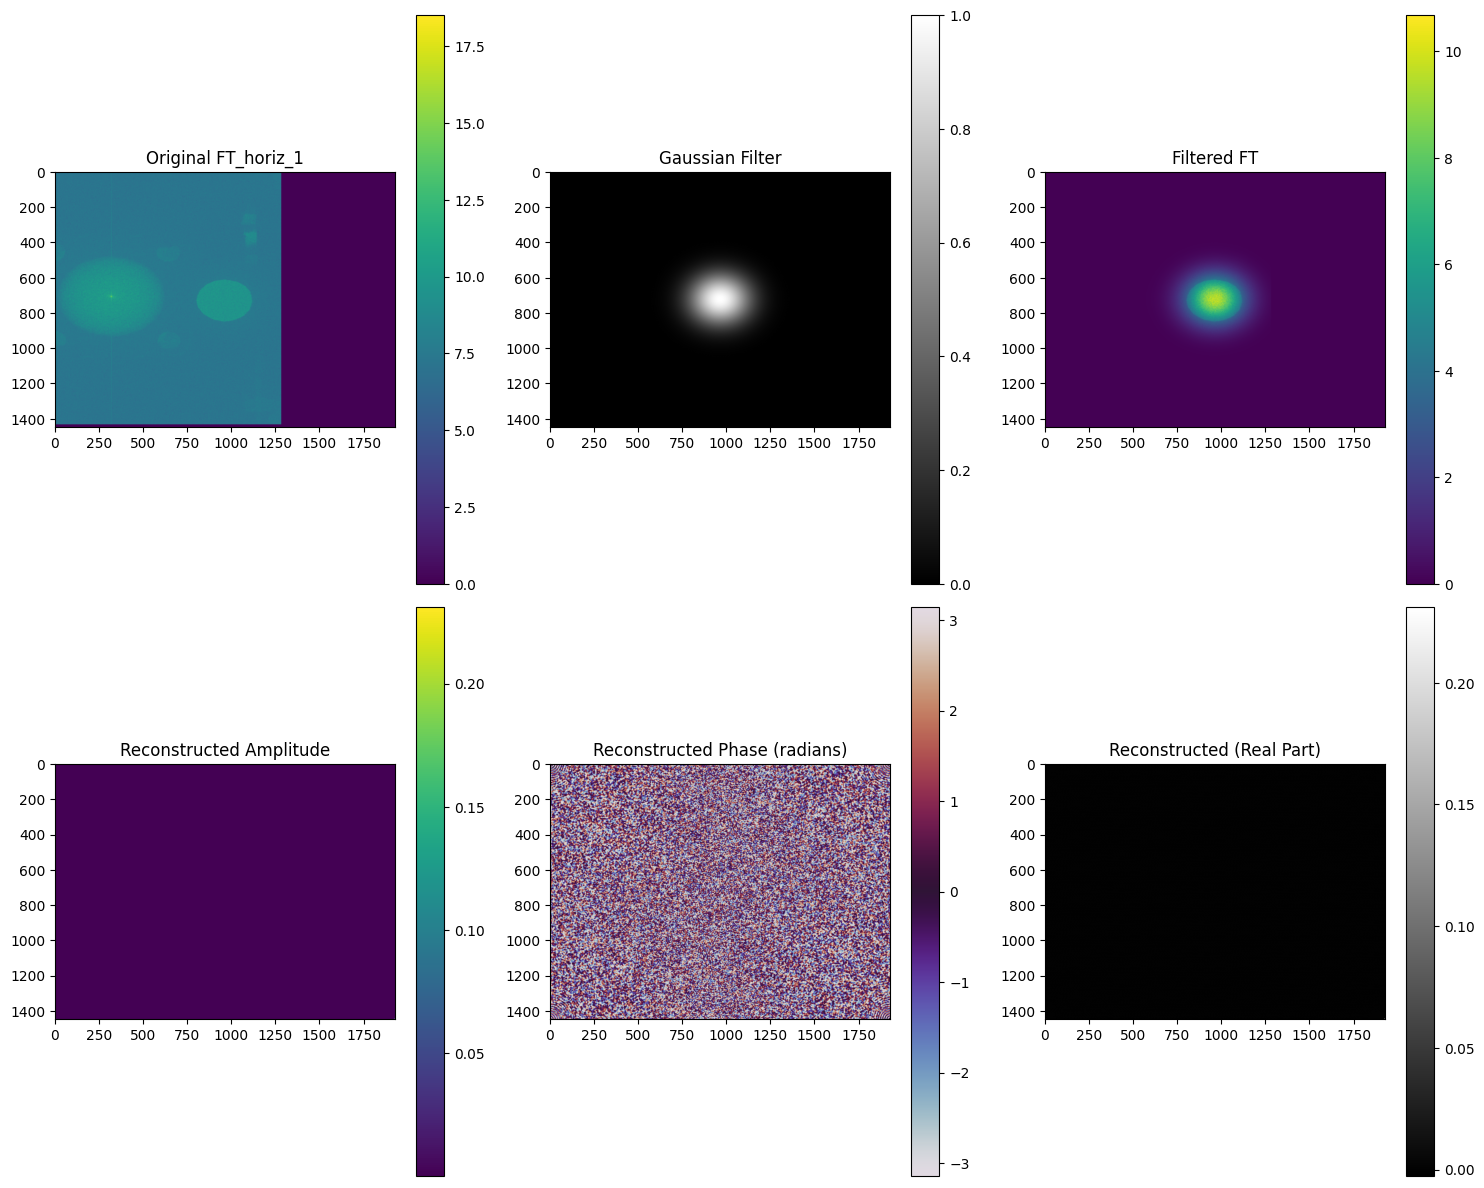

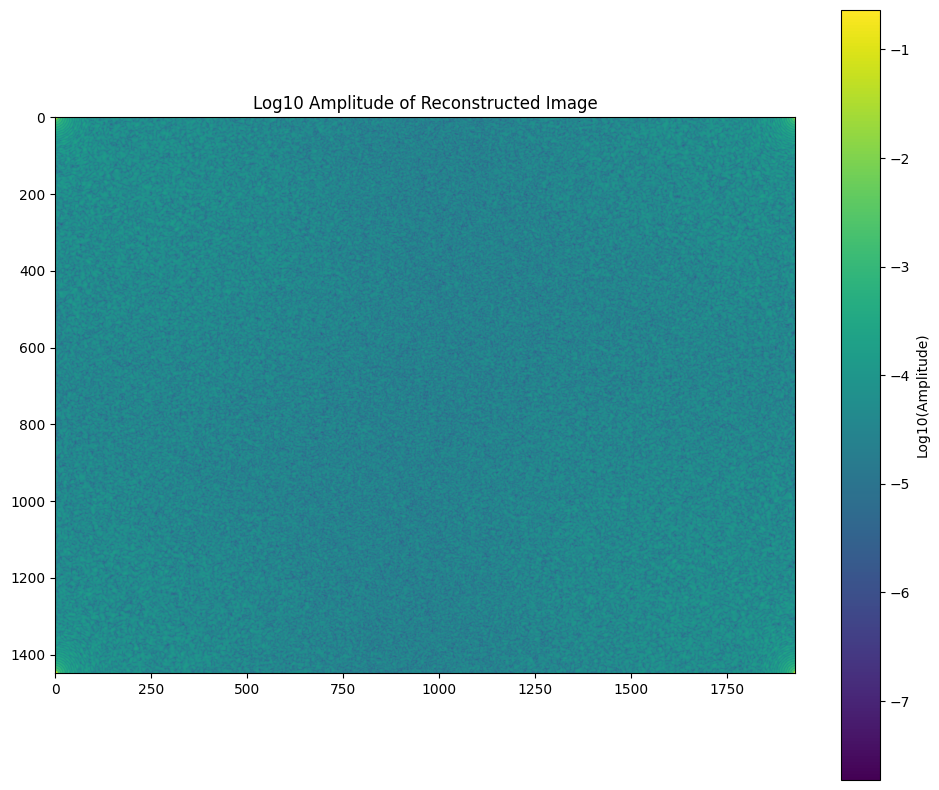

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import ifft2, fftshift, ifftshift
import scipy.fftpack as fftpack

# Assuming filtered_FT is already created using your pass filter
# If not, create it with: filtered_FT = FT_horiz_1 * notch_filter

# Perform inverse FFT
reconstructed_complex = fftpack.ifft2(fftpack.ifftshift(filtered_FT))

# Extract amplitude and phase from complex result
amplitude = np.abs(reconstructed_complex)
phase = np.angle(reconstructed_complex)  # Returns values in radians (-π to π)

# Also calculate real part as in your code
real_part = np.real(reconstructed_complex)

# Plot results
plt.figure(figsize=(15, 12))

# Plot original FFT
plt.subplot(231)
plt.imshow(FT_horiz_1, cmap='viridis')
plt.title('Original FT_horiz_1')
plt.colorbar()

# Plot Gaussian filter 
plt.subplot(232)
plt.imshow(notch_filter, cmap='gray')
plt.title('Gaussian Filter')
plt.colorbar()

# Plot filtered FFT
plt.subplot(233)
plt.imshow(filtered_FT, cmap='viridis')
plt.title('Filtered FT')
plt.colorbar()

# Plot the amplitude (magnitude)
plt.subplot(234)
plt.imshow(amplitude, cmap='viridis')
plt.title('Reconstructed Amplitude')
plt.colorbar()

# Plot the phase
plt.subplot(235)
plt.imshow(phase, cmap='twilight')  # 'twilight' is good for phase visualization
plt.title('Reconstructed Phase (radians)')
plt.colorbar()

# Plot the real part (as in your code)
plt.subplot(236)
plt.imshow(real_part, cmap='gray')
plt.title('Reconstructed (Real Part)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Optional: Add logarithmic scale visualization for amplitude
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(amplitude + 1e-10), cmap='viridis')  # Adding small value to avoid log(0)
plt.title('Log10 Amplitude of Reconstructed Image')
plt.colorbar(label='Log10(Amplitude)')
plt.tight_layout()
plt.show()

# Question 4

Image shape: (1448, 1928)
Data type: uint8


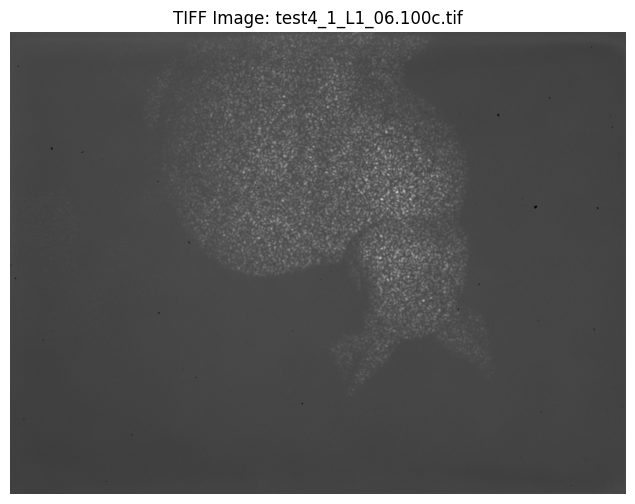

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Path to your TIFF file
file_path = "provided_resource/dataset_part_2/test4_1_L1_06.100c.tif"

# Read the TIFF file with OpenCV
try:
    # Use IMREAD_UNCHANGED to preserve the original data (e.g., 16-bit or multi-channel)
    img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

    
    # Display basic info
    print(f"Image shape: {img.shape}")
    print(f"Data type: {img.dtype}")
    
# Convert to RGB if it’s BGR, or keep as is if single-channel
    if len(img.shape) == 3 and img.shape[2] == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img
    
    # If RGB, convert to grayscale for FFT (or use a single channel)
    if len(img_rgb.shape) == 3:
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_rgb
    
    # Plot the image
    plt.figure(figsize=(8, 6))  # Set figure size (optional)
    plt.imshow(img_gray, cmap='gray' if len(img.shape) == 2 else None)  # Grayscale or RGB
    plt.title("TIFF Image: test4_1_L1_06.100c.tif")
    plt.axis('off')  # Hide axes (optional)
    plt.show()

except Exception as e:
    print(f"Error: {e}")

fshift shape: (1448, 1928)


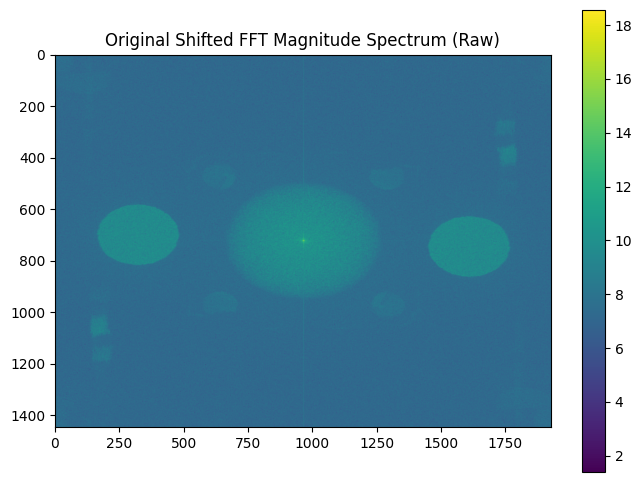

crop info y: 15:1448 ;x: 645:1928
paste info y: 0:1433 ;x: 0:1283


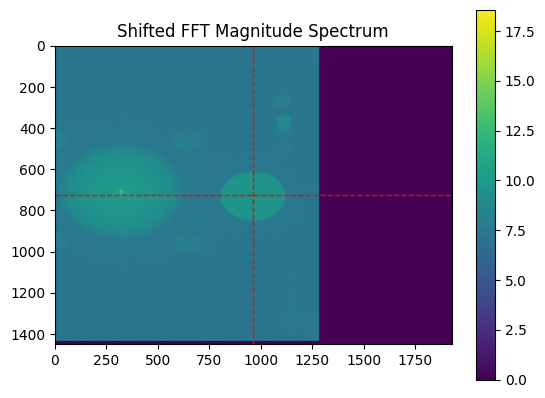

In [24]:
_,spectrum = compute_fft_spectrum(img_gray)
spectrum = np.log(spectrum )
print(f"fshift shape: {spectrum.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(spectrum, cmap='viridis')
plt.title("Original Shifted FFT Magnitude Spectrum (Raw)")
plt.colorbar()
plt.show()

FT_img = spectrum
FT_horiz_OX_shift = -645  # Shift left by 1205 pixels
FT_horiz_OY_shift = -15    # Shift up by 50 pixels
FT_horiz_1 = shifting(FT_img, FT_horiz_OX_shift, FT_horiz_OY_shift)
plt.imshow(FT_horiz_1)
plt.title("Shifted FFT Magnitude Spectrum")
# Add red dashed lines at the middle of x and y axes
height, width = FT_horiz_1.shape  # (1448, 1928)
mid_x = width // 2  # 964
mid_y = height // 2  # 724

plt.axvline(x=mid_x, color='red', linestyle='--', linewidth=1)  # Vertical line (x-axis)
plt.axhline(y=mid_y, color='red', linestyle='--', linewidth=1)  # Horizontal line (y-axis)

plt.axis('on')  # Turn on axes to see the lines clearly
plt.colorbar()
plt.show()

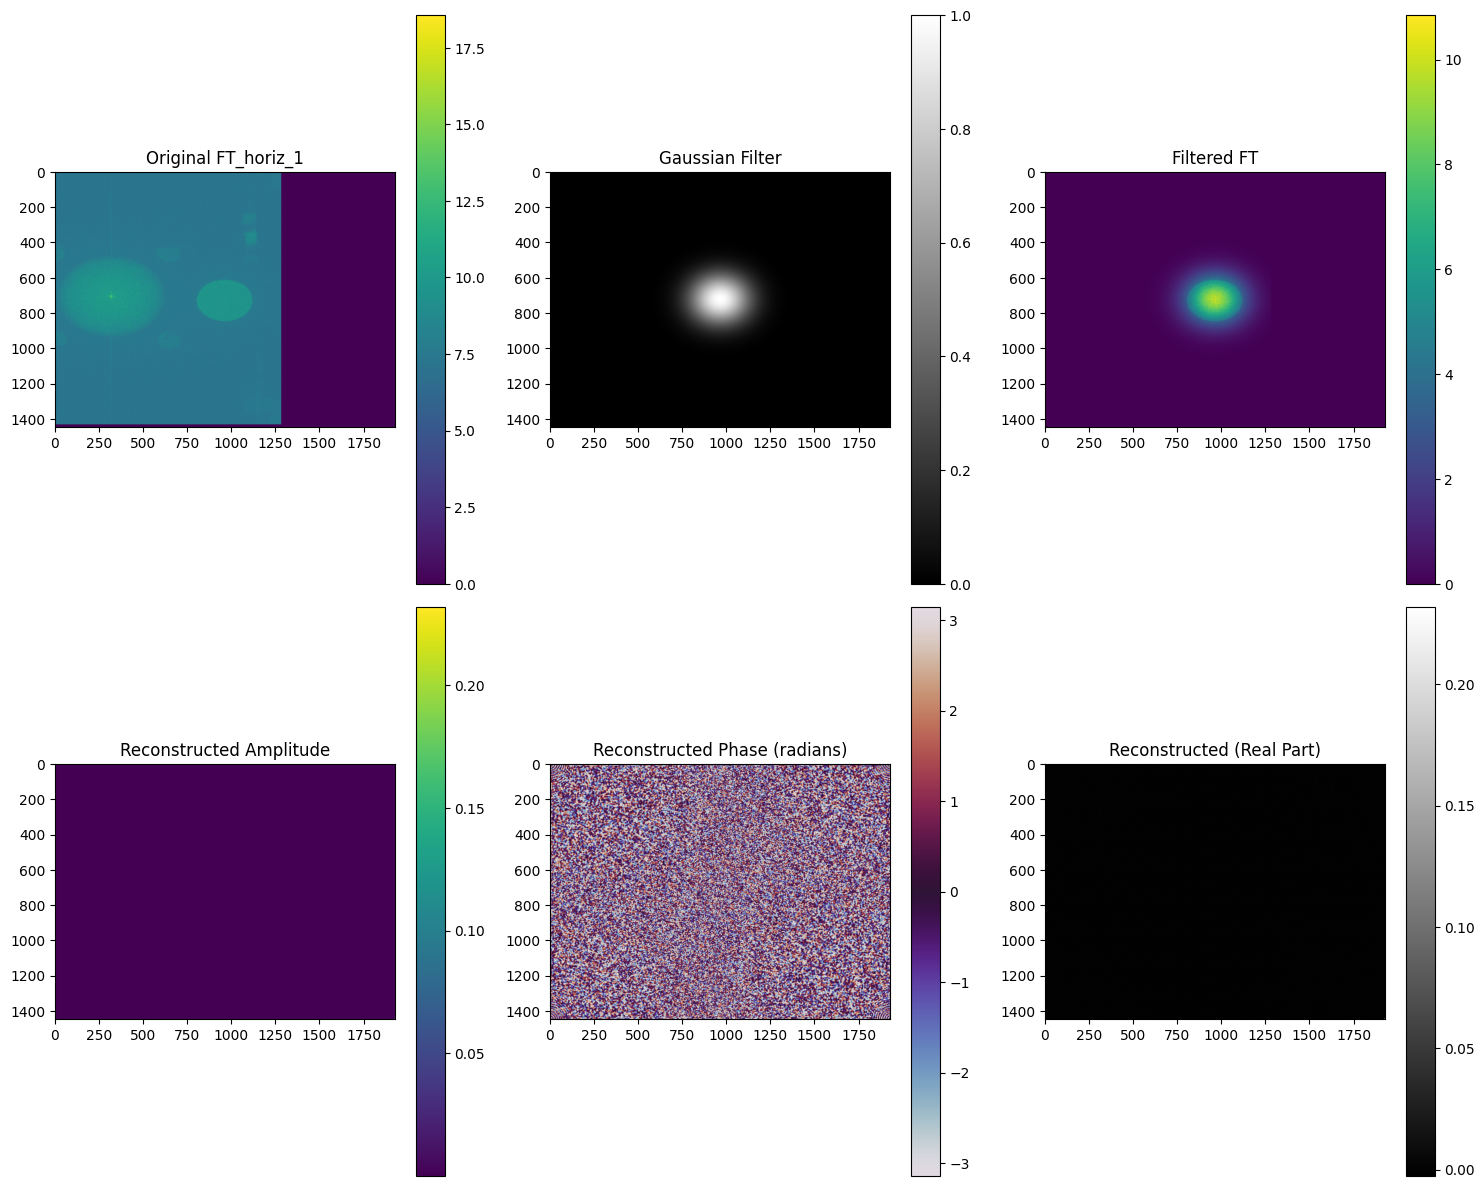

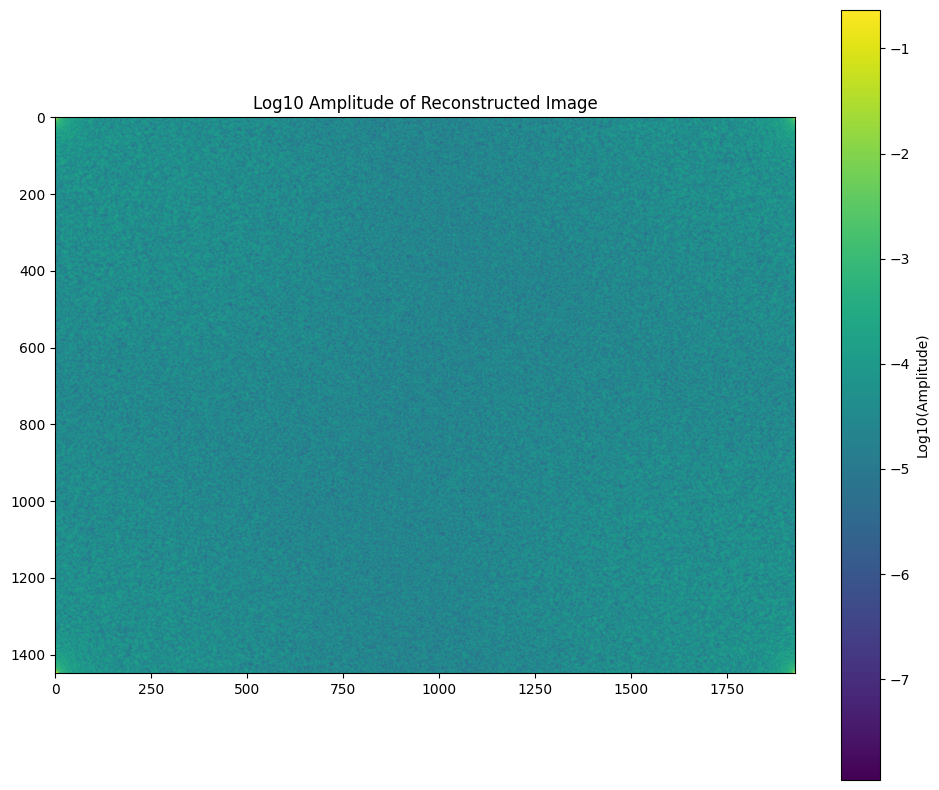

In [25]:
# Get dimensions of FT_horiz_1
height, width = FT_horiz_1.shape  # (1448, 1928)
mid_x = width // 2  # 964
mid_y = height // 2  # 724


# Size of the elliptical feature (standard deviations)
sigma_y, sigma_x = 100, 120  # Adjust these to match the spread of the ellipse

# Create the notch filter
notch_filter = create_gaussian_notch_filter((height, width), mid_y, mid_x, sigma_y, sigma_x,'pass')

# Apply the filter to FT_horiz_1
filtered_FT = FT_horiz_1 * notch_filter

# Perform inverse FFT
reconstructed_complex = fftpack.ifft2(fftpack.ifftshift(filtered_FT))

# Extract amplitude and phase from complex result
amplitude = np.abs(reconstructed_complex)
phase = np.angle(reconstructed_complex)  # Returns values in radians (-π to π)

# Also calculate real part as in your code
real_part = np.real(reconstructed_complex)

# Plot results
plt.figure(figsize=(15, 12))

# Plot original FFT
plt.subplot(231)
plt.imshow(FT_horiz_1, cmap='viridis')
plt.title('Original FT_horiz_1')
plt.colorbar()

# Plot Gaussian filter 
plt.subplot(232)
plt.imshow(notch_filter, cmap='gray')
plt.title('Gaussian Filter')
plt.colorbar()

# Plot filtered FFT
plt.subplot(233)
plt.imshow(filtered_FT, cmap='viridis')
plt.title('Filtered FT')
plt.colorbar()

# Plot the amplitude (magnitude)
plt.subplot(234)
plt.imshow(amplitude, cmap='viridis')
plt.title('Reconstructed Amplitude')
plt.colorbar()

# Plot the phase
plt.subplot(235)
plt.imshow(phase, cmap='twilight')  # 'twilight' is good for phase visualization
plt.title('Reconstructed Phase (radians)')
plt.colorbar()

# Plot the real part (as in your code)
plt.subplot(236)
plt.imshow(real_part, cmap='gray')
plt.title('Reconstructed (Real Part)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Optional: Add logarithmic scale visualization for amplitude
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(amplitude + 1e-10), cmap='viridis')  # Adding small value to avoid log(0)
plt.title('Log10 Amplitude of Reconstructed Image')
plt.colorbar(label='Log10(Amplitude)')
plt.tight_layout()
plt.show()